## Plot branchwater output
Used branchwater to look for microbes that are common in pig gut. 
Returns metagenomes. Count for each metagenome how many of these microbes are present. 
If more of these microbes (out of N) are present, is the metagenome likely to be pig? (yes)

In [1]:
# base checkout of workflow directory is here:
BASE='/home/ctbrown/scratch3/2025-workflow-core99/'

BP_THRESHOLD=20000

BASE_OUTPUTS=BASE+'/outputs.cds/branchwater.cds3/'

# where to place figures
FIG_OUT=BASE+'/outputs.figures/'

In [2]:
# imports
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# remove shitty entries with shitty metatada
def remove_unnannotated(df: pl.DataFrame) -> pl.DataFrame:
    bad_values = [
        "metagenome",
        "gut metagenome",
        "feces metagenome",
        "manure metagenome",
        "bacterium",
        "unidentified",
        "null"
    ]
    return df.filter(~pl.col("organism").is_in(bad_values))


# group by organism and count number of bacteria per SRA 
def pivot_count(df: pl.DataFrame) -> pl.DataFrame:
    return (
        df
        .group_by(["broad_cat", "count"])
        .len()  # count occurrences
        .pivot(
            values="len",
            index="broad_cat",
            on="count"
        )
        .fill_null(0)  # optional: fill missing with 0
    )

# set mapping for "categories of interest" I like human v pig v neither. 
category_map_simple = {
    'human associated': ['human', 'homo', 'sapiens'],
    'pig': ['pig', 'sus', 'scrofa']}

# Function to assign category based on keywords above
def get_broad_cat_simple(organism):
    for cat, keywords in category_map_simple.items():
        if any(keyword.lower() in str(organism).lower() for keyword in keywords):
            return cat
    return 'other'  

# colormap plotting
colors = {
    'pig': '#264653',
    'human associated': '#e76f51',
    'other': '#f4a261',
    'pig/other': '#2a9d8f',
    'pig-associated': '#e9c46a'
    }

In [4]:
dirpath = BASE_OUTPUTS+'/manysearch.*.parquet'

all_bw_df = pl.scan_parquet(dirpath).collect()
all_bw_df = all_bw_df.with_columns(
    species=pl.col("query_name"),
    acc=pl.col("match_name"),
    intersect_bp=pl.col("scaled")*pl.col("intersect_hashes"),
)
all_bw_df = all_bw_df.select(["species", "acc", "containment", "intersect_bp"])

n_species = all_bw_df['species'].n_unique()
n_acc = all_bw_df['acc'].n_unique()
print(f"loaded {len(all_bw_df)} branchwater results for {n_species} species containing {n_acc} metagenomes")

loaded 9893748 branchwater results for 32 species containing 714231 metagenomes


In [5]:
names_3216_df = (pl.read_csv('../3216.manifest.csv')
                 .with_columns(acc=pl.col('name'))
                 ['acc'].unique().to_frame()
                )
assert len(names_3216_df) == 3216, len(names_3216_df)
names_3216 = set(names_3216_df['acc'].to_list())

all_bw_df = all_bw_df.filter(~pl.col('acc').is_in(names_3216))
print(f"remaining: {len(all_bw_df)} branchwater results for {n_species} species containing {n_acc} metagenomes")

remaining: 9795180 branchwater results for 32 species containing 714231 metagenomes


In [6]:
# get metadata, only compare WGS
metadata_df = (
    pl.scan_parquet("/group/ctbrowngrp5/sra-metagenomes/20241128-metadata.parquet")
    .filter(pl.col("acc") != "NP")
    .filter(pl.col("assay_type") == "WGS")
    .select(["acc", "organism", "bioproject", "mbases", "host", "project_name"]) 
    .collect()
)
print(f"found metadata records for {len(metadata_df)} WGS metagenome data sets from the SRA")

found metadata records for 703916 WGS metagenome data sets from the SRA


In [7]:
rename_df = []
for organism in metadata_df['organism'].unique().to_list():
    simpleorg = 'other'
    if organism:
        for kw in ['human', 'homo']:
            if kw in organism.lower():
                simpleorg = 'human'
                break
        for kw in ['pig', 'sus', 'scrofa']:
            if kw in organism.lower():
                simpleorg = 'pig'
                break
    rename_df.append(dict(organism=organism, broad_cat=simpleorg))

rename_df = pl.DataFrame(rename_df)
rename_df['broad_cat'].value_counts().sort(by='count', descending=True)

broad_cat,count
str,u32
"""other""",10208
"""human""",165
"""pig""",36


In [8]:
metadata2_df = metadata_df.join(rename_df, on='organism', how='left', coalesce=True)
assert len(metadata2_df) == len(metadata_df)
metadata2_df

acc,organism,bioproject,mbases,host,project_name,broad_cat
str,str,str,i64,str,str,str
"""SRR28523869""","""human metagenome""","""PRJNA1095378""",258,"""[""Homo sapiens""]""",null,"""human"""
"""SRR19901137""","""Streptococcus suis""","""PRJNA854064""",40,"""[""Homo sapiens""]""",null,"""other"""
"""SRR24962475""","""Escherichia coli""","""PRJNA982891""",88,"""[""Homo sapiens""]""",null,"""other"""
"""SRR29161330""","""biofilm metagenome""","""PRJNA1116137""",3,"""[""metagenome""]""",null,"""other"""
"""SRR26668739""","""bovine gut metagenome""","""PRJNA1035769""",129,"""[""Bos taurus""]""",null,"""other"""
…,…,…,…,…,…,…
"""ERR4174288""","""human gut metagenome""","""PRJEB36461""",1017,null,"""[""Impact of Laparoscopic Roux-…","""human"""
"""ERR3160109""","""human gut metagenome""","""PRJEB23292""",133,null,"""[""Major microbiota dysbiosis i…","""human"""
"""ERR2709457""","""human gut metagenome""","""PRJEB27799""",964,null,"""[""Prediction of the intestinal…","""human"""


In [9]:
n_pig = len(metadata2_df.filter(pl.col('broad_cat') == 'pig'))
n_human = len(metadata2_df.filter(pl.col('broad_cat') == 'human'))

print(f"{n_pig} pig, {n_human} human metag")

9500 pig, 303365 human metag


In [10]:
n_pig_deep = len(metadata2_df.filter((pl.col('broad_cat') == 'pig') & (pl.col('mbases') >= 1000)))
n_human_deep = len(metadata2_df.filter((pl.col('broad_cat') == 'human') & (pl.col('mbases') >= 1000)))
print(f"deep: {n_pig_deep} pig, {n_human_deep} human metag")

deep: 5465 pig, 155835 human metag


In [11]:
all_bw_df = all_bw_df.join(metadata2_df, on="acc", how="left")
print(f"{all_bw_df['species'].n_unique()} species")

32 species


In [12]:
CORE_SPECIES=set([ x.strip() for x in open('../inputs.cds/names.list') ])
all_bw_df = all_bw_df.filter(pl.col("species").is_in(CORE_SPECIES))
print(f"{all_bw_df['species'].n_unique()} species left after filtering for core")
assert all_bw_df['species'].n_unique() == len(CORE_SPECIES)

16 species left after filtering for core


In [13]:
# apply hash threshold
bw_df = all_bw_df.filter(pl.col("intersect_bp") >= BP_THRESHOLD)

# remove unnanotated metags (metagenome, gut metagenome, etc)
df = remove_unnannotated(bw_df)

# update with organism broad category
df = df.join(rename_df, on='organism', how='inner')


# count number of orgs (out of 16) in each mG
counts_df = (
    df
    .group_by(["acc", "broad_cat"])
    .len()
    .rename({"len": "count"})
)

print(counts_df)

# pivot for plotting
pl_dfp = pivot_count(counts_df)

# sort columns by number
assert pl_dfp.columns[0] == 'broad_cat'
sorted_cols = list(sorted(pl_dfp.columns[1:], key=lambda x: int(x)))
pl_dfp = pl_dfp.select(['broad_cat'] + sorted_cols)

print(pl_dfp)

shape: (71_496, 3)
┌─────────────┬───────────┬───────┐
│ acc         ┆ broad_cat ┆ count │
│ ---         ┆ ---       ┆ ---   │
│ str         ┆ str       ┆ u32   │
╞═════════════╪═══════════╪═══════╡
│ ERR10125334 ┆ human     ┆ 1     │
│ ERR589866   ┆ human     ┆ 1     │
│ SRR1491759  ┆ human     ┆ 1     │
│ SRR21460703 ┆ other     ┆ 2     │
│ SRR28382426 ┆ human     ┆ 1     │
│ …           ┆ …         ┆ …     │
│ SRR17408286 ┆ other     ┆ 3     │
│ SRR17737865 ┆ human     ┆ 1     │
│ SRR24976288 ┆ other     ┆ 1     │
│ ERR4682359  ┆ other     ┆ 10    │
│ ERR505083   ┆ human     ┆ 1     │
└─────────────┴───────────┴───────┘
shape: (3, 17)
┌───────────┬───────┬──────┬──────┬───┬─────┬─────┬─────┬──────┐
│ broad_cat ┆ 1     ┆ 2    ┆ 3    ┆ … ┆ 13  ┆ 14  ┆ 15  ┆ 16   │
│ ---       ┆ ---   ┆ ---  ┆ ---  ┆   ┆ --- ┆ --- ┆ --- ┆ ---  │
│ str       ┆ u32   ┆ u32  ┆ u32  ┆   ┆ u32 ┆ u32 ┆ u32 ┆ u32  │
╞═══════════╪═══════╪══════╪══════╪═══╪═════╪═════╪═════╪══════╡
│ human     ┆ 19699 ┆ 4774 ┆ 

In [14]:
# transpose with sensible column names
df_cm = pl_dfp.transpose(include_header=True, header_name='index',
                 column_names=pl_dfp['broad_cat'].to_list())

# get rid of first row
df_cm = df_cm.tail(-1)

# change the values to all integer
df_cm = df_cm.with_columns(
    pl.col("index").str.to_integer(),
    pl.col("pig").str.to_integer(),
    pl.col("human").str.to_integer(),
    pl.col("other").str.to_integer()
)

df_cm = df_cm.with_columns(
    pl.col("pig").cum_sum(reverse=True).alias("cm_pig"),
    pl.col("human").cum_sum(reverse=True).alias("cm_human"),
    pl.col("other").cum_sum(reverse=True).alias("cm_other"),
)


df_cm = df_cm.with_columns(
    (pl.col("cm_pig") / (pl.col("cm_pig") + pl.col("cm_human") + pl.col("cm_other"))).alias("f_pig"),
    (pl.col("cm_human") / (pl.col("cm_pig") + pl.col("cm_human") + pl.col("cm_other"))).alias("f_human"),
    (pl.col("cm_other") / (pl.col("cm_pig") + pl.col("cm_human") + pl.col("cm_other"))).alias("f_other"),
)

print(df_cm)

shape: (16, 10)
┌───────┬───────┬──────┬───────┬───┬──────────┬──────────┬──────────┬──────────┐
│ index ┆ human ┆ pig  ┆ other ┆ … ┆ cm_other ┆ f_pig    ┆ f_human  ┆ f_other  │
│ ---   ┆ ---   ┆ ---  ┆ ---   ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ i64   ┆ i64   ┆ i64  ┆ i64   ┆   ┆ i64      ┆ f64      ┆ f64      ┆ f64      │
╞═══════╪═══════╪══════╪═══════╪═══╪══════════╪══════════╪══════════╪══════════╡
│ 1     ┆ 19699 ┆ 148  ┆ 11917 ┆ … ┆ 38043    ┆ 0.058157 ┆ 0.409743 ┆ 0.5321   │
│ 2     ┆ 4774  ┆ 148  ┆ 5860  ┆ … ┆ 26126    ┆ 0.100926 ┆ 0.241518 ┆ 0.657556 │
│ 3     ┆ 2269  ┆ 114  ┆ 4900  ┆ … ┆ 20266    ┆ 0.133402 ┆ 0.166563 ┆ 0.700035 │
│ 4     ┆ 1162  ┆ 112  ┆ 3101  ┆ … ┆ 15366    ┆ 0.172982 ┆ 0.117829 ┆ 0.709189 │
│ 5     ┆ 643   ┆ 123  ┆ 2318  ┆ … ┆ 12265    ┆ 0.210271 ┆ 0.080442 ┆ 0.709288 │
│ …     ┆ …     ┆ …    ┆ …     ┆ … ┆ …        ┆ …        ┆ …        ┆ …        │
│ 12    ┆ 12    ┆ 163  ┆ 690   ┆ … ┆ 3610     ┆ 0.429528 ┆ 0.008254 ┆ 0.562218 │
│ 13    ┆ 10

Text(0, 0.5, 'Fraction of metagenomes')

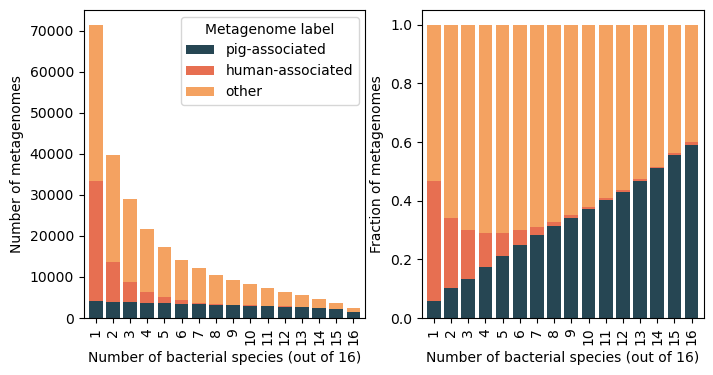

In [15]:
xlabels = df_cm['index'].to_list()
weights = {}
for col in ('cm_pig', 'cm_human', 'cm_other', 'f_pig', 'f_human', 'f_other'):
    weights[col] = df_cm[col].to_list()

labels = {}
labels['cm_human'] = 'human-associated'
labels['cm_other'] = 'other'
labels['cm_pig'] = 'pig-associated'
labels['f_human'] = 'human-associated'
labels['f_other'] = 'other'
labels['f_pig'] = 'pig-associated'

# colormap plotting
colors = {
    'cm_pig': '#264653',
    'cm_human': '#e76f51',
    'cm_other': '#f4a261',
    'f_pig': '#264653',
    'f_human': '#e76f51',
    'f_other': '#f4a261',
    }

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

bottom = np.zeros(len(xlabels))
for name in 'cm_pig', 'cm_human', 'cm_other':
    counts = weights[name]
    axes[0].bar(xlabels, counts, label=labels[name], bottom=bottom, color=colors[name])
    bottom += np.array(counts)

bottom = np.zeros(len(xlabels))
for name in 'f_pig', 'f_human', 'f_other':
    counts = weights[name] 
    axes[1].bar(xlabels, counts, label=labels[name], bottom=bottom, color=colors[name])
    bottom += np.array(counts)

for ax in axes:
    ax.set_xlim(0.3, 16.7)
    ax.set_xlabel('Number of bacterial species (out of 16)')
    ax.tick_params(axis='x', labelrotation=90)
    ax.set_xticks(xlabels)

axes[0].legend(title='Metagenome label', loc='upper right')
axes[0].set_ylabel('Number of metagenomes')
axes[1].set_ylabel('Fraction of metagenomes')

## Figure 1: Core bacteria largely select against human-associated metagenomes.

21-mer search of 700,000 public metagenomes with each of 16 bacterial species pangenomes  found almost 200,000 metagenomes containing at least one species at a containment threshold of 5%. Over 163,000 of these metagenomes were human-associated. Filtering metagenomes based on the number of contained species progressively eliminated the large majority of human metagenomes; when requiring 12 or more species, 80% of the pig metagenomes were retained while only 0.2% of the human metagenomes were retained.

(0.0, 60000.0)

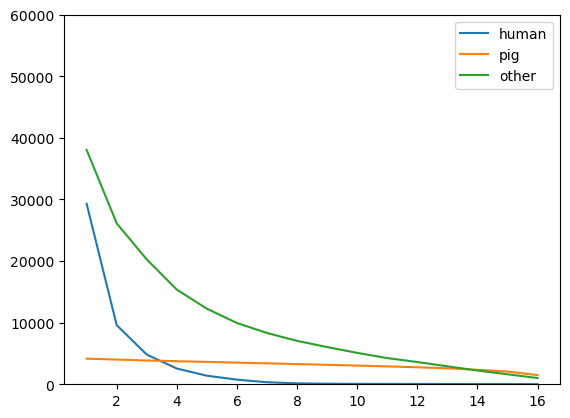

In [16]:
plt.plot(df_cm['index'], df_cm['cm_human'], label='human')
plt.plot(df_cm['index'], df_cm['cm_pig'], label='pig')
plt.plot(df_cm['index'], df_cm['cm_other'], label='other')

plt.legend(loc='upper right')
plt.ylim(0, 60000)

In [17]:
all_bw_df['broad_cat'].value_counts()

broad_cat,count
str,u32
"""pig""",70398
"""human""",1695638
"""other""",2945419
null,801474


In [18]:
d = metadata2_df['broad_cat'].value_counts().to_dict(as_series=False)

pig_idx = d['broad_cat'].index('pig')
n_orig_pig = d['count'][pig_idx]

human_idx = d['broad_cat'].index('human')
n_orig_human = d['count'][human_idx]

f_orig_pig = n_orig_pig / (n_orig_pig + n_orig_human)
f_orig_human = n_orig_human / (n_orig_pig + n_orig_human)

orig_pig_ratio = n_orig_pig / (n_orig_pig + n_orig_human)
orig_human_ratio = n_orig_human / (n_orig_pig + n_orig_human)

print(orig_pig_ratio, orig_human_ratio)

0.030364534224026338 0.9696354657759737


In [35]:

enrich_df = df_cm.with_columns(
    enrich_pig = (pl.col("cm_pig") / (pl.col("cm_pig") + pl.col("cm_human")) / orig_pig_ratio),
    enrich_human = (pl.col("cm_human") / (pl.col("cm_pig") + pl.col("cm_human")) / orig_human_ratio),
)
print(enrich_df)

shape: (16, 12)
┌───────┬───────┬──────┬───────┬───┬──────────┬──────────┬────────────┬──────────────┐
│ index ┆ human ┆ pig  ┆ other ┆ … ┆ f_human  ┆ f_other  ┆ enrich_pig ┆ enrich_human │
│ ---   ┆ ---   ┆ ---  ┆ ---   ┆   ┆ ---      ┆ ---      ┆ ---        ┆ ---          │
│ i64   ┆ i64   ┆ i64  ┆ i64   ┆   ┆ f64      ┆ f64      ┆ f64        ┆ f64          │
╞═══════╪═══════╪══════╪═══════╪═══╪══════════╪══════════╪════════════╪══════════════╡
│ 1     ┆ 19699 ┆ 148  ┆ 11917 ┆ … ┆ 0.409743 ┆ 0.5321   ┆ 4.093387   ┆ 0.903129     │
│ 2     ┆ 4774  ┆ 148  ┆ 5860  ┆ … ┆ 0.241518 ┆ 0.657556 ┆ 9.706156   ┆ 0.727363     │
│ 3     ┆ 2269  ┆ 114  ┆ 4900  ┆ … ┆ 0.166563 ┆ 0.700035 ┆ 14.646229  ┆ 0.572663     │
│ 4     ┆ 1162  ┆ 112  ┆ 3101  ┆ … ┆ 0.117829 ┆ 0.709189 ┆ 19.589506  ┆ 0.417862     │
│ 5     ┆ 643   ┆ 123  ┆ 2318  ┆ … ┆ 0.080442 ┆ 0.709288 ┆ 23.820362  ┆ 0.285371     │
│ …     ┆ …     ┆ …    ┆ …     ┆ … ┆ …        ┆ …        ┆ …          ┆ …            │
│ 12    ┆ 12    ┆ 163  ┆ 69

(0.0, 40.0)

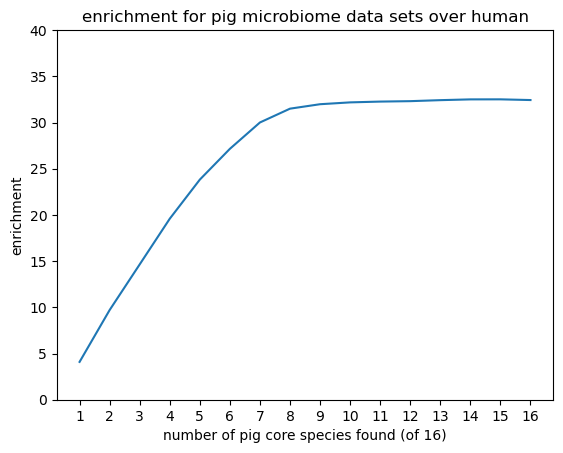

In [39]:
# plt.plot(enrich_df['index'], enrich_df['enrich_human'], label='human enrichment')
plt.plot(enrich_df['index'], enrich_df['enrich_pig'], label='pig enrichment')
plt.title('enrichment for pig microbiome data sets over human')
plt.xlabel('number of pig core species found (of 16)')
plt.ylabel('enrichment')
plt.xticks(range(1, 17))

#plt.legend(loc='upper right')
plt.ylim(0, 40)

## Export the `other` accessions and data sets >= 8 species

In [20]:
other_df = counts_df.filter((pl.col('count') >= 8) & (pl.col("broad_cat") == "other"))
other_df = other_df.join(metadata2_df, on='acc', coalesce=True).select(
    ['acc', 'bioproject', 'organism', 'count', 'broad_cat', 'mbases', 'host', 'project_name']
)

In [21]:
other_df['organism'].value_counts().sort(by='count')

organism,count
str,u32
"""leaf litter metagenome""",1
"""mine drainage metagenome""",1
"""Muntiacus reevesi""",1
"""microbial fuel cell metagenome""",1
"""Canis lupus familiaris""",1
…,…
"""wastewater metagenome""",309
"""bovine gut metagenome""",475
"""sediment metagenome""",739


## Pick out organisms that are pig associated -

In [22]:
known_d = {}
known_d['bovine gut metagenome'] = 1
known_d['goat gut metagenome'] = 1
known_d['bovine metagenome'] = 1
known_d['Bos taurus'] = 1
known_d['Equus asinus asinus'] = 1
known_d['sheep gut metagenome'] = 1
known_d['Equus asinus'] = 1
known_d['goat gut metagenome'] = 1
known_d['mouse gut metagenome'] = 0
known_d['termite gut metagenome'] = 0
known_d['invertebrate metagenome'] = 0

xx = []
for k, v in known_d.items():
    xx.append(dict(organism=k, is_pig_assoc=v))
xx_df = pl.DataFrame(xx)

more_known_organisms_df = xx_df.join(other_df, on='organism', how='inner')
more_known_organisms_acc = set(more_known_organisms_df['acc'].to_list())
remaining_other_df = other_df.filter(~pl.col('acc').is_in(more_known_organisms_acc))

with pl.Config(tbl_rows=-1):
    print(remaining_other_df['organism'].value_counts().sort(by='count', descending=True).filter(pl.col("count") > 10))

shape: (44, 2)
┌────────────────────────────────┬───────┐
│ organism                       ┆ count │
│ ---                            ┆ ---   │
│ str                            ┆ u32   │
╞════════════════════════════════╪═══════╡
│ marine metagenome              ┆ 1381  │
│ soil metagenome                ┆ 1011  │
│ sediment metagenome            ┆ 739   │
│ wastewater metagenome          ┆ 309   │
│ rhizosphere metagenome         ┆ 270   │
│ marine sediment metagenome     ┆ 197   │
│ seawater metagenome            ┆ 181   │
│ freshwater metagenome          ┆ 145   │
│ wetland metagenome             ┆ 132   │
│ groundwater metagenome         ┆ 108   │
│ bioreactor metagenome          ┆ 105   │
│ air metagenome                 ┆ 102   │
│ freshwater sediment metagenome ┆ 85    │
│ dust metagenome                ┆ 81    │
│ synthetic metagenome           ┆ 78    │
│ lake water metagenome          ┆ 73    │
│ peat metagenome                ┆ 67    │
│ terrestrial metagenome         ┆ 66  

In [23]:
main_bioprojects_df = (other_df['bioproject']
 .value_counts()                              # aggregate by counts
 .filter(pl.col('count') >= 50)               # select only counts above 50
 .drop_nulls()                                # eliminate null
 .sort(by='count'))

main_bioprojects_write = main_bioprojects_df.join(metadata2_df, on='bioproject', how='inner')
main_bioprojects_write = (main_bioprojects_write
                          .select(['bioproject', 'project_name'])
                          .unique()
                          .fill_null("")
                          .with_columns(manual_annot=pl.lit('(unannotated)'),
                                        is_pig_assoc=pl.lit(""),
)
                         )

with pl.Config(tbl_rows=-1):
    print(main_bioprojects_write)

main_bioprojects_set = set(main_bioprojects_df['bioproject'].to_list())

shape: (19, 4)
┌──────────────┬─────────────────────────────────┬───────────────┬──────────────┐
│ bioproject   ┆ project_name                    ┆ manual_annot  ┆ is_pig_assoc │
│ ---          ┆ ---                             ┆ ---           ┆ ---          │
│ str          ┆ str                             ┆ str           ┆ str          │
╞══════════════╪═════════════════════════════════╪═══════════════╪══════════════╡
│ PRJEB4352    ┆ ["Tara Oceans"]                 ┆ (unannotated) ┆              │
│ PRJEB21508   ┆ ["Ruminomics EU FP7"]           ┆ (unannotated) ┆              │
│ PRJEB9691    ┆                                 ┆ (unannotated) ┆              │
│ PRJNA379303  ┆                                 ┆ (unannotated) ┆              │
│ PRJEB9691    ┆ ["Tara Oceans Expedition (2009… ┆ (unannotated) ┆              │
│ PRJNA356291  ┆                                 ┆ (unannotated) ┆              │
│ PRJEB34634   ┆ ["REHAB"]                       ┆ (unannotated) ┆              │
│

In [24]:
remaining_other_df = other_df.filter(~pl.col('bioproject').is_in(main_bioprojects_set))

# shuffle in a stable, repeatable way so that we can output repeatedly without messing things up
remaining_subset_df = remaining_other_df.sort(by='acc').sample(None, seed=42, fraction=1.0, shuffle=True)
remaining_subset_df = remaining_subset_df.with_columns(
    manual_annot=pl.lit("(unnanotated)"),
    is_pig_assoc=pl.lit(""),
)
remaining_subset_df

acc,bioproject,organism,count,broad_cat,mbases,host,project_name,manual_annot,is_pig_assoc
str,str,str,u32,str,i64,str,str,str,str
"""SRR8436516""","""PRJNA502373""","""seawater metagenome""",8,"""other""",28210,"""[""not applicable""]""",null,"""(unnanotated)""",""""""
"""SRR9651508""","""PRJNA539066""","""wetland metagenome""",9,"""other""",88209,null,null,"""(unnanotated)""",""""""
"""SRR3181140""","""PRJNA309291""","""bovine gut metagenome""",11,"""other""",15442,"""[""Bos taurus""]""",null,"""(unnanotated)""",""""""
"""SRR11615638""","""PRJNA620681""","""soil metagenome""",9,"""other""",48419,"""[""not applicable""]""",null,"""(unnanotated)""",""""""
"""SRR4435568""","""PRJNA214227""","""bovine gut metagenome""",8,"""other""",10036,"""[""Bison bison""]""",null,"""(unnanotated)""",""""""
…,…,…,…,…,…,…,…,…,…
"""ERR4678594""","""PRJEB40798""","""wastewater metagenome""",10,"""other""",13362,null,null,"""(unnanotated)""",""""""
"""SRR24085918""","""PRJNA951521""","""soil metagenome""",9,"""other""",37006,null,null,"""(unnanotated)""",""""""
"""SRR9052924""","""PRJNA541820""","""mouse gut metagenome""",15,"""other""",46038,"""[""C57BL/6""]""",null,"""(unnanotated)""",""""""


In [25]:
import os
try:
    os.mkdir('../outputs.branchwater/lists')
except:
    pass

remaining_subset_df.write_csv('../outputs.branchwater/lists/other_accs.csv')
main_bioprojects_write.write_csv('../outputs.branchwater/lists/main_bioprojects.csv')
more_known_organisms_df.write_csv('../outputs.branchwater/lists/other_known_orgs.csv')

# Explore results of manual curation

In [26]:
bioprojects_mc_df = (pl.read_csv('../inputs.mancur/main_bioprojects.csv')
                     .filter(pl.col("ignore") != 1)
                     .select(pl.exclude(["ignore"]))
                    )
print(bioprojects_mc_df)

# take only top 100 to eliminate Lake Diwa samples :sob:
acc_mc_df = pl.read_csv('../inputs.mancur/other_accs.csv').head(100)
acc_mc_df = acc_mc_df.filter(
    (pl.col("manual_annot") != "(unnanotated)") &
    (pl.col("ignore") != 1)
).with_columns(
    pl.col("is_pig_assoc").str.to_integer()
).select(pl.exclude(["ignore"]))

print(acc_mc_df)

# semi-manually curated too
more_known_organisms_df = pl.read_csv('../outputs.branchwater/lists/other_known_orgs.csv')
print(more_known_organisms_df)

shape: (18, 5)
┌─────────────┬─────────────────────────────┬────────────────────────────┬──────────────┬──────────┐
│ bioproject  ┆ project_name                ┆ manual_annot               ┆ is_pig_assoc ┆ is_ocean │
│ ---         ┆ ---                         ┆ ---                        ┆ ---          ┆ ---      │
│ str         ┆ str                         ┆ str                        ┆ i64          ┆ i64      │
╞═════════════╪═════════════════════════════╪════════════════════════════╪══════════════╪══════════╡
│ PRJNA629394 ┆                             ┆ Matagenomic data from      ┆ 0            ┆ 1        │
│             ┆                             ┆ mangrve …                  ┆              ┆          │
│ PRJEB4352   ┆                             ┆ Shotgun Sequencing of Tara ┆ 0            ┆ 1        │
│             ┆                             ┆ Oce…                       ┆              ┆          │
│ PRJEB31266  ┆ ["Metagenomic sequencing of ┆ Metagenomic sequencing of  ┆ 1

In [27]:
expanded_bioprojects_mc_df = (bioprojects_mc_df
                              .join(other_df, on='bioproject', coalesce=True, how='inner')
                              .select(['acc', 'bioproject', 'manual_annot', 'is_pig_assoc', 'is_ocean'])
                              .filter(pl.col("is_ocean") != 1)
                             )
print(expanded_bioprojects_mc_df)
print(expanded_bioprojects_mc_df['is_pig_assoc'].value_counts())
                                       

shape: (581, 5)
┌────────────┬─────────────┬─────────────────────────────────┬──────────────┬──────────┐
│ acc        ┆ bioproject  ┆ manual_annot                    ┆ is_pig_assoc ┆ is_ocean │
│ ---        ┆ ---         ┆ ---                             ┆ ---          ┆ ---      │
│ str        ┆ str         ┆ str                             ┆ i64          ┆ i64      │
╞════════════╪═════════════╪═════════════════════════════════╪══════════════╪══════════╡
│ ERR3224576 ┆ PRJEB31266  ┆ Metagenomic sequencing of the … ┆ 1            ┆ 0        │
│ ERR3574843 ┆ PRJEB34634  ┆ Detailed study at the genetic … ┆ 1            ┆ 0        │
│ ERR2019396 ┆ PRJEB21508  ┆ Deep metagenome sequencing of … ┆ 1            ┆ 0        │
│ SRR5371511 ┆ PRJNA356291 ┆ bovine fecal metagenome raw se… ┆ 1            ┆ 0        │
│ SRR5679035 ┆ PRJNA379303 ┆ The objective of this study wa… ┆ 1            ┆ 0        │
│ …          ┆ …           ┆ …                               ┆ …            ┆ …        │
│ ERR

In [28]:
acc_mc_df

acc,bioproject,organism,count,broad_cat,mbases,host,project_name,manual_annot,is_pig_assoc,is_ocean
str,str,str,i64,str,i64,str,str,str,i64,i64
"""SRR8436516""","""PRJNA502373""","""seawater metagenome""",8,"""other""",28210,"""[""not applicable""]""",null,"""Seawater microbial communities…",0,1
"""SRR9651508""","""PRJNA539066""","""wetland metagenome""",9,"""other""",88209,null,null,"""Wetland soil microbial communi…",0,1
"""SRR3181140""","""PRJNA309291""","""bovine gut metagenome""",11,"""other""",15442,"""[""Bos taurus""]""",null,"""cow gut""",1,0
"""SRR11615638""","""PRJNA620681""","""soil metagenome""",9,"""other""",48419,"""[""not applicable""]""",null,"""Soil microbial communities fro…",1,0
"""SRR4435568""","""PRJNA214227""","""bovine gut metagenome""",8,"""other""",10036,"""[""Bison bison""]""",null,"""Metagenomic survey sequencing …",1,0
…,…,…,…,…,…,…,…,…,…,…
"""SRR22560182""","""PRJNA909573""","""bovine metagenome""",10,"""other""",12494,"""[""bovine""]""",null,"""calf feces""",1,0
"""SRR29699998""","""PRJNA1131488""","""sediment metagenome""",8,"""other""",24149,null,null,"""metagenome of brackish water l…",0,0
"""SRR29445157""","""PRJNA1125130""","""Fibrobacteria""",11,"""other""",10347,"""[""horse""]""",null,"""Changes in intestinal flora be…",1,0


In [29]:
expanded_acc_mc_df = (acc_mc_df
                      .filter(pl.col("is_ocean") != 1)
                      .join(other_df, on='acc', coalesce=True, how='inner')
                      .select(['acc', 'bioproject', 'manual_annot', 'is_pig_assoc', 'is_ocean'])
                     )
print(expanded_acc_mc_df)
print(expanded_acc_mc_df['is_pig_assoc'].value_counts())

shape: (48, 5)
┌─────────────┬──────────────┬─────────────────────────────────┬──────────────┬──────────┐
│ acc         ┆ bioproject   ┆ manual_annot                    ┆ is_pig_assoc ┆ is_ocean │
│ ---         ┆ ---          ┆ ---                             ┆ ---          ┆ ---      │
│ str         ┆ str          ┆ str                             ┆ i64          ┆ i64      │
╞═════════════╪══════════════╪═════════════════════════════════╪══════════════╪══════════╡
│ SRR7097860  ┆ PRJNA441489  ┆ Forest soil microbial communit… ┆ 0            ┆ 0        │
│ SRR3181140  ┆ PRJNA309291  ┆ cow gut                         ┆ 1            ┆ 0        │
│ SRR9032617  ┆ PRJNA539719  ┆ Lab incubated soil microbial c… ┆ 0            ┆ 0        │
│ SRR3053162  ┆ PRJNA292471  ┆ The purpose of this study was … ┆ 1            ┆ 0        │
│ SRR636559   ┆ PRJNA183510  ┆ hydrocarbon metagenome          ┆ 0            ┆ 0        │
│ …           ┆ …            ┆ …                               ┆ …         

In [30]:
print(more_known_organisms_df['is_pig_assoc'].value_counts())

shape: (2, 2)
┌──────────────┬───────┐
│ is_pig_assoc ┆ count │
│ ---          ┆ ---   │
│ i64          ┆ u32   │
╞══════════════╪═══════╡
│ 1            ┆ 825   │
│ 0            ┆ 105   │
└──────────────┴───────┘


# Combine the large-scale bulk curated ones just to get numbers...

In [31]:
bulk_df = expanded_bioprojects_mc_df.clone().select(['acc', 'bioproject', 'is_pig_assoc'])
seen_accs = set(bulk_df['acc'].to_list())

to_join_df = (more_known_organisms_df.filter(~pl.col("acc").is_in(seen_accs))
              .select(['acc', 'bioproject', 'is_pig_assoc'])
             )

bulk_df = pl.concat([bulk_df, to_join_df])
print(bulk_df['is_pig_assoc'].value_counts())

#combined_mc_df = pl.concat([, expanded_bioprojects_mc_df])
#print(combined_mc_df['is_pig_assoc'].value_counts())

shape: (2, 2)
┌──────────────┬───────┐
│ is_pig_assoc ┆ count │
│ ---          ┆ ---   │
│ i64          ┆ u32   │
╞══════════════╪═══════╡
│ 1            ┆ 1117  │
│ 0            ┆ 105   │
└──────────────┴───────┘


In [32]:
expanded_acc_mc_df['is_pig_assoc'].value_counts()

is_pig_assoc,count
i64,u32
0,29
1,19


In [33]:
224 / (224 + 196)


0.5333333333333333